# Why xarray?

xhycom returns [xarray](https://docs.xarray.dev) Datasets.  If you have not
used xarray before, this page explains why that is a good thing.

---

## From raw indices to labelled dimensions

A NumPy array is a grid of numbers.  The only way to refer to a location is
by its integer position:

```python
arr[0, 5, 100, 200]   # what does this mean?
```

An **xarray Dataset** wraps the same numbers but gives every axis a name, attaches
coordinate values, and carries metadata.  Here is a small toy example with the
same structure as a HYCOM archive — two variables on a `(time, k, y, x)` grid:

In [1]:
import numpy as np
import xarray as xr
import cftime

ny, nx, nk, nt = 20, 30, 10, 12  # small grid for illustration

time  = [cftime.DatetimeGregorian(2020, m, 1) for m in range(1, nt + 1)]
k     = np.arange(1, nk + 1)
dens  = np.linspace(26.0, 28.0, nk)       # target sigma-2 density per layer
lon2d = np.tile(np.linspace(-10, 10, nx), (ny, 1))
lat2d = np.tile(np.linspace(50, 70, ny)[:, None], (1, nx))

rng  = np.random.default_rng(0)
dims = ("time", "k", "y", "x")
coords = dict(
    time=("time", time),
    k=("k", k, {"long_name": "layer index", "units": "1", "axis": "Z"}),
    dens=("k", dens, {"long_name": "target sigma-2 layer density", "units": "kg m-3"}),
    lon=(["y", "x"], lon2d, {"long_name": "longitude", "units": "degrees_east",  "standard_name": "longitude"}),
    lat=(["y", "x"], lat2d, {"long_name": "latitude",  "units": "degrees_north", "standard_name": "latitude"}),
)

ds = xr.Dataset(
    {
        "temp": xr.DataArray(
            rng.normal(5, 3, (nt, nk, ny, nx)),
            dims=dims, coords=coords,
            attrs={"long_name": "sea water potential temperature", "units": "degC"},
        ),
        "salin": xr.DataArray(
            rng.normal(35, 1, (nt, nk, ny, nx)),
            dims=dims, coords=coords,
            attrs={"long_name": "sea water salinity", "units": "PSU"},
        ),
        "srfhgt": xr.DataArray(
            rng.normal(0, 5000, (nt, ny, nx)),
            dims=("time", "y", "x"), coords={k: v for k, v in coords.items() if k not in ("k", "dens")},
            attrs={"long_name": "sea surface height", "units": "Pa"},
        ),
    },
    attrs={"description": "Toy ocean dataset (same structure as a HYCOM archive)"},
)
ds

<xarray.Dataset> Size: 1MB
Dimensions:  (time: 12, k: 10, y: 20, x: 30)
Coordinates:
  * time     (time) object 96B 2020-01-01 00:00:00 ... 2020-12-01 00:00:00
  * k        (k) int64 80B 1 2 3 4 5 6 7 8 9 10
    dens     (k) float64 80B 26.0 26.22 26.44 26.67 ... 27.33 27.56 27.78 28.0
    lon      (y, x) float64 5kB -10.0 -9.31 -8.621 -7.931 ... 8.621 9.31 10.0
    lat      (y, x) float64 5kB 50.0 50.0 50.0 50.0 50.0 ... 70.0 70.0 70.0 70.0
Dimensions without coordinates: y, x
Data variables:
    temp     (time, k, y, x) float64 576kB 5.377 4.604 6.921 ... 10.27 5.168
    salin    (time, k, y, x) float64 576kB 32.44 34.55 34.07 ... 35.24 35.59
    srfhgt   (time, y, x) float64 58kB -6.647e+03 -635.5 ... 5.214e+03
Attributes:
    description:  Toy ocean dataset (same structure as a HYCOM archive)

Click the icons on the right of each row to expand coordinates and attributes.
Notice:

- Every axis has a **name** — `time`, `k`, `y`, `x` — not just an integer position.
- `lon` and `lat` are **2-D curvilinear** coordinates: they live on the `(y, x)` grid,
  just like a real ocean model on a non-rectangular grid.
- `dens` gives each vertical layer a **physical label** (target sigma-2 density),
  so you can write `ds["temp"].sel(dens=27.0, method="nearest")` instead of `arr[:, 5, :, :]`.
- Every variable carries **CF-style attributes** (`long_name`, `units`) that appear
  automatically in plot labels.

---

## Coordinates travel with the data

Operations on an xarray object preserve coordinates automatically.  Slice a
layer, take a time mean, compute an anomaly — the result always knows where
it is:

In [2]:
# Select surface layer and take a time mean — coordinates are preserved automatically
sst_mean = ds["temp"].isel(k=0).mean("time")
sst_mean

<xarray.DataArray 'temp' (y: 20, x: 30)> Size: 5kB
array([[4.49613298, 4.82798084, 3.30136389, 5.24302273, 5.81710217,
        5.25808985, 6.22346355, 4.19645876, 5.88739858, 4.76628531,
        4.88347417, 4.60155376, 4.66092057, 5.42924823, 4.92985383,
        4.96666037, 6.37363088, 4.76892471, 5.13895149, 5.85705093,
        4.41965531, 5.07794453, 4.49980205, 5.90155666, 5.95883614,
        5.99369286, 3.02222098, 4.84304793, 3.47142542, 4.71514191],
       [4.22540109, 5.02764166, 3.89466327, 5.99957853, 4.04206223,
        5.17582447, 5.44023634, 5.92491076, 5.60205596, 4.56262881,
        5.09245145, 5.18176807, 4.86460777, 4.29143486, 5.22939139,
        6.09650067, 5.71176562, 4.95496655, 4.96653507, 5.60478466,
        4.80325627, 5.39526157, 5.96105618, 5.0385708 , 4.38118054,
        3.76238749, 5.47089344, 4.44839623, 4.24289887, 3.65937114],
       [4.20766584, 4.51441481, 4.4486331 , 2.87743268, 4.48701748,
        4.5780106 , 5.45851012, 5.95721997, 5.58286811, 4.44527348,
        6.59369433, 4.60638076, 4.65108344, 5.46039457, 5.18542486,
        5.29270798, 3.58552177, 4.71932838, 6.18540324, 4.5579556 ,
        5.6491876 , 4.86902926, 4.33864119, 5.74451508, 4.75044865,
        3.72659193, 5.18721568, 5.11248662, 5.29448538, 6.02935357],
       [5.48034114, 4.44975344, 4.60267035, 4.80793269, 5.37670629,
        4.563093  , 4.66433469, 5.35726249, 3.78690324, 5.61068043,
...
        3.94610453, 3.18401636, 3.71646145, 4.43729776, 5.5073521 ,
        5.18690552, 5.28329469, 4.41689295, 6.45973727, 4.62682623],
       [4.52041382, 6.39514059, 4.41282125, 5.5275527 , 6.56798967,
        5.41445805, 5.47712146, 5.93748723, 4.81265524, 5.51234996,
        5.44742824, 4.91465904, 3.42891314, 4.22864721, 3.82372354,
        6.26377656, 4.86902194, 5.33199637, 5.32325795, 5.49784115,
        5.39495439, 5.81019206, 5.20906634, 6.26609038, 4.4266159 ,
        5.237327  , 3.67216623, 4.88932123, 3.40165156, 3.57099877],
       [3.34752729, 6.07626989, 4.40935618, 3.52280523, 6.07465843,
        3.40645781, 2.78146854, 3.42403301, 4.92466896, 5.11261783,
        5.33269822, 4.17501649, 5.09337563, 5.5027163 , 3.97657581,
        5.61419913, 5.61749952, 6.53217472, 4.25067714, 6.39623669,
        5.66717638, 4.8257111 , 3.842357  , 4.59043952, 5.51492238,
        5.43796308, 7.66401062, 4.11364749, 4.66576816, 3.8071525 ],
       [5.03941047, 6.31086418, 5.72736335, 4.81302109, 3.72079676,
        6.39029313, 5.10725839, 4.33199012, 2.83002489, 4.96997614,
        4.94872889, 3.96301739, 6.10587176, 4.35128376, 4.18382449,
        5.93445922, 5.44718828, 5.21718118, 4.81585582, 6.73073586,
        5.28021211, 4.77759747, 5.64729846, 4.49536223, 4.58174361,
        6.39118856, 3.42504117, 3.6984635 , 3.49841477, 5.83300251]])
Coordinates:
    lon      (y, x) float64 5kB -10.0 -9.31 -8.621 -7.931 ... 8.621 9.31 10.0
    lat      (y, x) float64 5kB 50.0 50.0 50.0 50.0 50.0 ... 70.0 70.0 70.0 70.0
    k        int64 8B 1
    dens     float64 8B 26.0
Dimensions without coordinates: y, x
Attributes:
    long_name:  sea water potential temperature
    units:      degC

`sst_mean` still knows its `lon`, `lat`, `k`, and `dens` — they were not discarded
by `.isel()` or `.mean()`.  With raw NumPy you would have to carry those arrays
separately and reattach them after every operation.

---

## Plotting just works

Because coordinates are embedded in the data, xarray's `.plot()` method
automatically labels axes, titles, and colourbars:

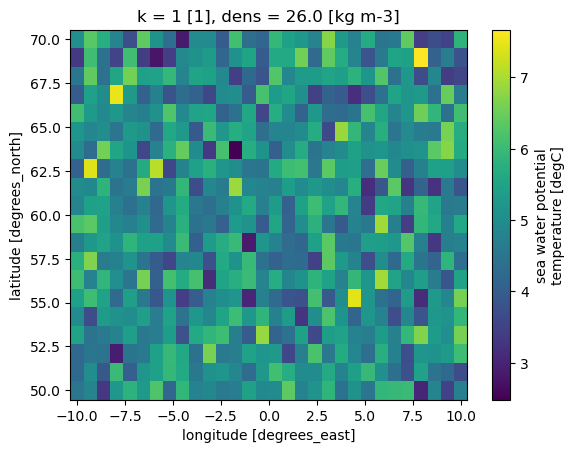

In [4]:
sst_mean.plot(x="lon", y="lat")

With NumPy + Matplotlib you would need to pass `lon` and `lat` explicitly to
`pcolormesh`, set axis labels by hand, and add the colourbar yourself.

---

## Larger-than-memory data via Dask

xarray integrates with [Dask](https://docs.dask.org) to represent datasets
that are far larger than available RAM.  Instead of reading data immediately,
xarray builds a *computation graph*: a recipe for what to do when you finally
ask for the result.

```
                          open_mfdataset(..., chunks={"time": 1})
                          ┌─────────────────────────────────────┐
30 years of .ab files ───►│  Dask-backed xr.Dataset             │
(~1 TB on disk)           │  in memory: ~100 MB (graph only)    │
                          └───────────────┬─────────────────────┘
                                          │  .isel(k=0).mean("time")
                                          ▼
                          ┌─────────────────────────────────────┐
                          │  lazy computation graph             │
                          │  (still nothing read from disk)     │
                          └───────────────┬─────────────────────┘
                                          │  .compute()
                                          ▼
                          ┌─────────────────────────────────────┐
                          │  result: (y, x) NumPy array         │
                          │  only the needed chunks were read   │
                          └─────────────────────────────────────┘
```

This is what makes it possible to compute a 30-year mean SST on a laptop
without running out of memory.

---

## The broader ecosystem

An xarray Dataset plugs into a large ecosystem of scientific Python tools
without any glue code:

| Task | Tool |
|---|---|
| Interactive maps | [hvPlot](https://hvplot.holoviz.org) / [GeoViews](https://geoviews.org) |
| Parallel computation | [Dask](https://docs.dask.org) |
| Cloud-optimised storage | [Zarr](https://zarr.dev) |
| Regridding | [xESMF](https://xesmf.readthedocs.io) |
| Statistics | [xskillscore](https://xskillscore.readthedocs.io), [climpred](https://climpred.readthedocs.io) |
| Filtering | [xrft](https://xrft.readthedocs.io), [scipy](https://docs.scipy.org) |

Because xhycom returns standard xarray objects, all of these work on HYCOM
output immediately — no adapters or format conversions required.